# Pré-processamento em Machine Learning

Este notebook para explicar as principais opções de pré-processamento em Machine Learning, com foco em:

- valores ausentes;
- remoção de linhas/colunas;
- imputação com média, mediana e moda;
- label encoding;
- one-hot encoding;
- normalização e padronização;
- tratamento de outliers;
- relação entre pré-processamento e tipo de algoritmo.

Ideia Geral: **o pré-processamento depende do tipo de dado e do algoritmo escolhido**.

## Mapa geral de decisão

### 1. Valores ausentes
- **Remover linhas**: quando poucos registros têm nulos.
- **Remover colunas**: quando a coluna tem muitos nulos e baixa utilidade.
- **Imputar com média**: dados numéricos sem forte presença de outliers.
- **Imputar com mediana**: dados numéricos com outliers.
- **Imputar com moda**: dados categóricos.

### 2. Variáveis categóricas
- **Label Encoding**: apropriado para o **target** e para categorias **ordinais**.
- **One-Hot Encoding**: apropriado para variáveis categóricas **nominais**.

### 3. Escalonamento
- **Normalização (Min-Max)**: traz os valores para um intervalo como `[0,1]`.
- **Padronização (Z-score)**: centraliza em média 0 e desvio padrão 1.

### 4. Outliers
- Detectar com IQR, boxplot ou z-score.
- Remover, limitar ou transformar depende do contexto.
- Modelos lineares, KNN, SVM e K-Means são mais sensíveis a outliers.
- Árvores e Random Forest tendem a ser menos sensíveis.

### 5. Regra Principal
Sempre:
1. separar `X` e `y`;
2. dividir treino e teste;
3. ajustar transformações apenas no treino;
4. aplicar as mesmas transformações no teste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)

## Criando um conjunto de dados sintético

Vamos construir um dataset pequeno com:
- colunas numéricas;
- colunas categóricas;
- valores ausentes;
- um outlier;
- um alvo categórico.

In [2]:
df = pd.DataFrame({
    'idade': [23, 45, 31, 52, 46, np.nan, 28, 100, 39, 41],
    'salario': [2500, 5200, 3100, 6100, np.nan, 2800, 3300, 150000, 4200, 3900],
    'sexo': ['F', 'M', 'F', 'M', 'F', 'M', np.nan, 'M', 'F', 'F'],
    'cidade': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'B', np.nan, 'A'],
    'risco': ['baixo', 'alto', 'baixo', 'alto', 'medio', 'baixo', 'medio', 'alto', 'baixo', 'medio'],
    'diagnostico': ['nao', 'sim', 'nao', 'sim', 'sim', 'nao', 'nao', 'sim', 'nao', 'sim']
})

df

,idade,salario,sexo,cidade,risco,diagnostico
0,23.0,2500.0,F,A,baixo,nao
1,45.0,5200.0,M,B,alto,sim
2,31.0,3100.0,F,A,baixo,nao
3,52.0,6100.0,M,C,alto,sim
4,46.0,NaN,F,B,medio,sim
5,NaN,2800.0,M,A,baixo,nao
6,28.0,3300.0,NaN,C,medio,nao
7,100.0,150000.0,M,B,alto,sim
8,39.0,4200.0,F,NaN,baixo,nao
9,41.0,3900.0,F,A,medio,sim


## 1. Inspeção inicial

Em qualquer pipeline real, o primeiro passo é inspecionar:
- tipos de dados;
- estatísticas básicas;
- quantidade de nulos.

In [3]:
print(df.info())
print()
print(df.describe(include='all'))
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   idade        9 non-null      float64
 1   salario      9 non-null      float64
 2   sexo         9 non-null      str    
 3   cidade       9 non-null      str    
 4   risco        10 non-null     str    
 5   diagnostico  10 non-null     str    
dtypes: float64(2), str(4)
memory usage: 612.0 bytes
None

             idade        salario sexo cidade  risco diagnostico
count     9.000000       9.000000    9      9     10          10
unique         NaN            NaN    2      3      3           2
top            NaN            NaN    F      A  baixo         nao
freq           NaN            NaN    5      4      4           5
mean     45.000000   20122.222222  NaN    NaN    NaN         NaN
std      22.627417   48718.009447  NaN    NaN    NaN         NaN
min      23.000000    2500.000000  NaN    NaN    NaN        

# 2. Tratamento de valores ausentes

## 2.1 Remover linhas com nulos

Essa estratégia é simples, mas pode gerar perda de informação.
Use quando:
- o número de linhas com nulos for pequeno;
- o dataset for grande;
- a perda não comprometer a amostra.

In [4]:
df_drop_rows = df.dropna()
df_drop_rows

,idade,salario,sexo,cidade,risco,diagnostico
0,23.0,2500.0,F,A,baixo,nao
1,45.0,5200.0,M,B,alto,sim
2,31.0,3100.0,F,A,baixo,nao
3,52.0,6100.0,M,C,alto,sim
7,100.0,150000.0,M,B,alto,sim
9,41.0,3900.0,F,A,medio,sim


## 2.2 Remover colunas com muitos nulos

Útil quando uma coluna:
- tem alta taxa de ausência;
- não parece relevante;
- seria difícil de imputar com qualidade.

Exemplo: remover uma coluna manualmente.

In [5]:
df_drop_col = df.drop(columns=['cidade'])
df_drop_col.head()

,idade,salario,sexo,risco,diagnostico
0,23.0,2500.0,F,baixo,nao
1,45.0,5200.0,M,alto,sim
2,31.0,3100.0,F,baixo,nao
3,52.0,6100.0,M,alto,sim
4,46.0,NaN,F,medio,sim


## 2.3 Imputação com média

Boa opção para variáveis numéricas com distribuição razoavelmente estável e sem muitos outliers.

In [6]:
df_media = df.copy()
df_media['idade'] = df_media['idade'].fillna(df_media['idade'].mean())
df_media['salario'] = df_media['salario'].fillna(df_media['salario'].mean())
df_media[['idade', 'salario']]

,idade,salario
0,23.0,2500.000000
1,45.0,5200.000000
2,31.0,3100.000000
3,52.0,6100.000000
4,46.0,20122.222222
5,45.0,2800.000000
6,28.0,3300.000000
7,100.0,150000.000000
8,39.0,4200.000000
9,41.0,3900.000000


## 2.4 Imputação com mediana

A mediana é mais robusta quando há outliers.
Neste dataset, a coluna `salario` tem um valor extremo (`150000`), então a mediana costuma ser mais apropriada que a média.

In [7]:
df_mediana = df.copy()
df_mediana['idade'] = df_mediana['idade'].fillna(df_mediana['idade'].median())
df_mediana['salario'] = df_mediana['salario'].fillna(df_mediana['salario'].median())
df_mediana[['idade', 'salario']]

,idade,salario
0,23.0,2500.0
1,45.0,5200.0
2,31.0,3100.0
3,52.0,6100.0
4,46.0,3900.0
5,41.0,2800.0
6,28.0,3300.0
7,100.0,150000.0
8,39.0,4200.0
9,41.0,3900.0


## 2.5 Imputação com moda

A moda é a estratégia mais comum para variáveis categóricas.

In [8]:
df_moda = df.copy()
for col in ['sexo', 'cidade']:
    df_moda[col] = df_moda[col].fillna(df_moda[col].mode()[0])

df_moda[['sexo', 'cidade']]

,sexo,cidade
0,F,A
1,M,B
2,F,A
3,M,C
4,F,B
5,M,A
6,F,C
7,M,B
8,F,A
9,F,A


## 2.6 Usando `SimpleImputer`

Além de `fillna`, é comum usar `SimpleImputer`, especialmente em fluxos mais estruturados.

In [9]:
num_imputer_media = SimpleImputer(strategy='mean')
num_imputer_mediana = SimpleImputer(strategy='median')
cat_imputer_moda = SimpleImputer(strategy='most_frequent')

df_imputer = df.copy()

df_imputer[['idade', 'salario']] = num_imputer_mediana.fit_transform(df_imputer[['idade', 'salario']])
df_imputer[['sexo', 'cidade']] = cat_imputer_moda.fit_transform(df_imputer[['sexo', 'cidade']])

df_imputer

,idade,salario,sexo,cidade,risco,diagnostico
0,23.0,2500.0,F,A,baixo,nao
1,45.0,5200.0,M,B,alto,sim
2,31.0,3100.0,F,A,baixo,nao
3,52.0,6100.0,M,C,alto,sim
4,46.0,3900.0,F,B,medio,sim
5,41.0,2800.0,M,A,baixo,nao
6,28.0,3300.0,F,C,medio,nao
7,100.0,150000.0,M,B,alto,sim
8,39.0,4200.0,F,A,baixo,nao
9,41.0,3900.0,F,A,medio,sim


# 3. Tratamento de outliers

Outliers são valores muito distantes do padrão.
Eles podem:
- distorcer média e desvio padrão;
- afetar regressão linear, KNN, SVM e K-Means;
- ter menos impacto em árvores.

Vamos detectar outliers usando o método do **IQR**.

In [10]:
q1 = df['salario'].quantile(0.25)
q3 = df['salario'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

outliers_salario = df[(df['salario'] < limite_inferior) | (df['salario'] > limite_superior)]
outliers_salario

Q1: 3100.0
Q3: 5200.0
IQR: 2100.0
Limite inferior: -50.0
Limite superior: 8350.0


,idade,salario,sexo,cidade,risco,diagnostico
7,100.0,150000.0,M,B,alto,sim


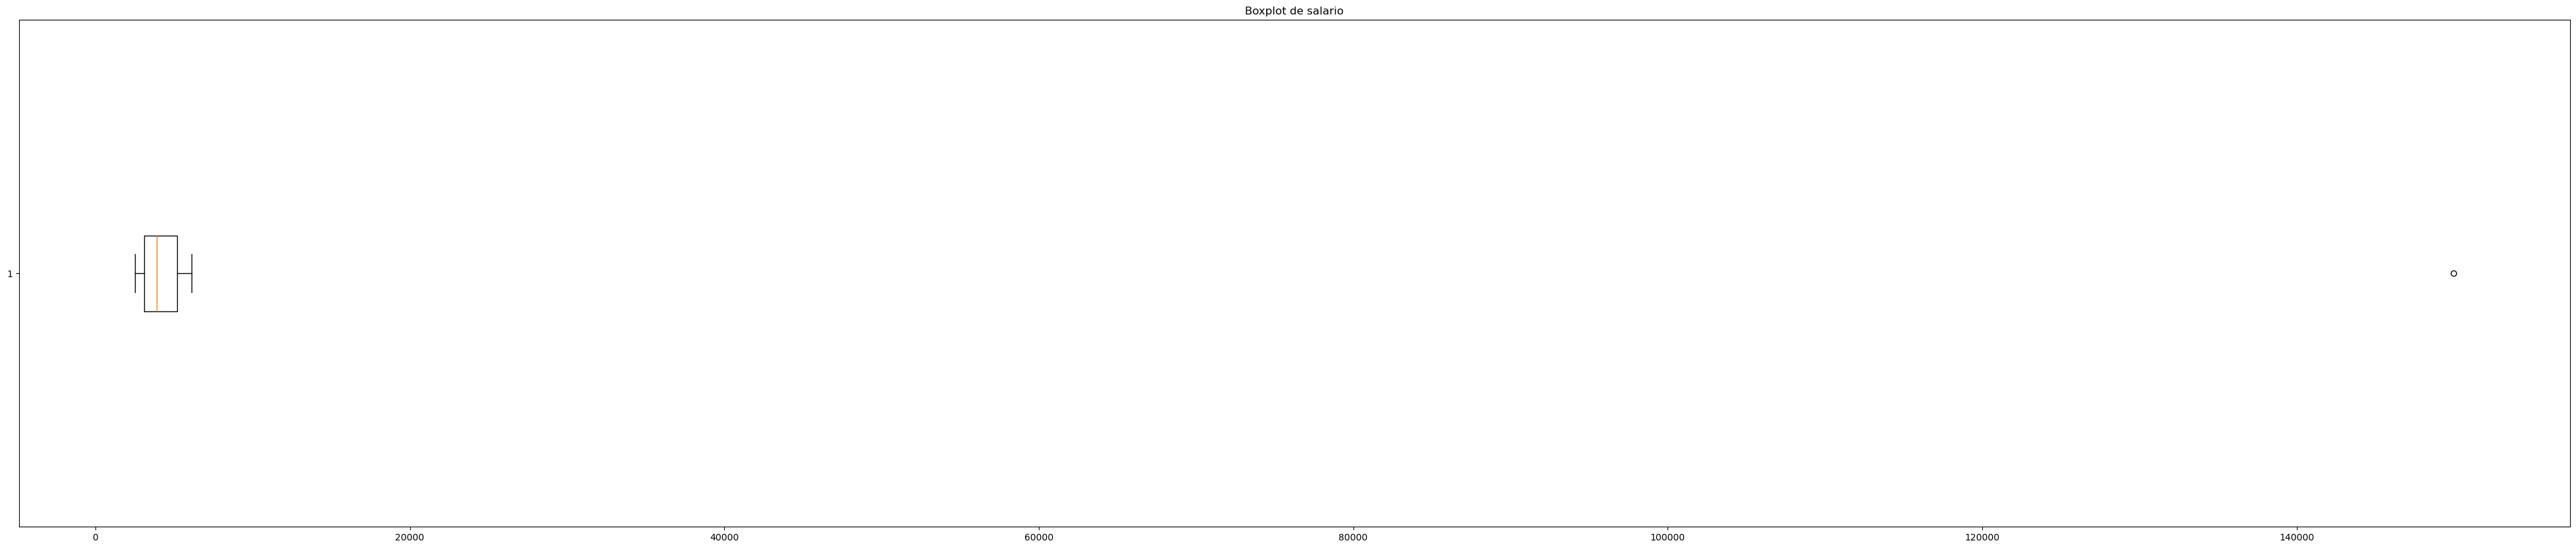

In [11]:
plt.figure(figsize=(50,10))
plt.boxplot(df['salario'].dropna(), vert=False)
plt.title('Boxplot de salario')
plt.show()

## 3.1 Remover outliers

Essa estratégia é útil quando o valor extremo parece erro ou ruído.

In [12]:
df_sem_outlier = df.copy()
df_sem_outlier = df_sem_outlier[
    (df_sem_outlier['salario'].isna()) |
    ((df_sem_outlier['salario'] >= limite_inferior) & (df_sem_outlier['salario'] <= limite_superior))
]
df_sem_outlier

,idade,salario,sexo,cidade,risco,diagnostico
0,23.0,2500.0,F,A,baixo,nao
1,45.0,5200.0,M,B,alto,sim
2,31.0,3100.0,F,A,baixo,nao
3,52.0,6100.0,M,C,alto,sim
4,46.0,NaN,F,B,medio,sim
5,NaN,2800.0,M,A,baixo,nao
6,28.0,3300.0,NaN,C,medio,nao
8,39.0,4200.0,F,NaN,baixo,nao
9,41.0,3900.0,F,A,medio,sim


## 3.2 Limitar outliers com `clip`

Em vez de remover linhas, podemos limitar os valores a um intervalo.
Isso preserva o registro, mas reduz o impacto do extremo.

In [13]:
df_clip = df.copy()
df_clip['salario_clipado'] = df_clip['salario'].clip(lower=limite_inferior, upper=limite_superior)
df_clip[['salario', 'salario_clipado']]

,salario,salario_clipado
0,2500.0,2500.0
1,5200.0,5200.0
2,3100.0,3100.0
3,6100.0,6100.0
4,NaN,NaN
5,2800.0,2800.0
6,3300.0,3300.0
7,150000.0,8350.0
8,4200.0,4200.0
9,3900.0,3900.0


## 3.3 Transformação logarítmica

Quando a variável é muito assimétrica, uma transformação log pode ajudar.
Como log exige valores positivos, é comum usar `log1p`.

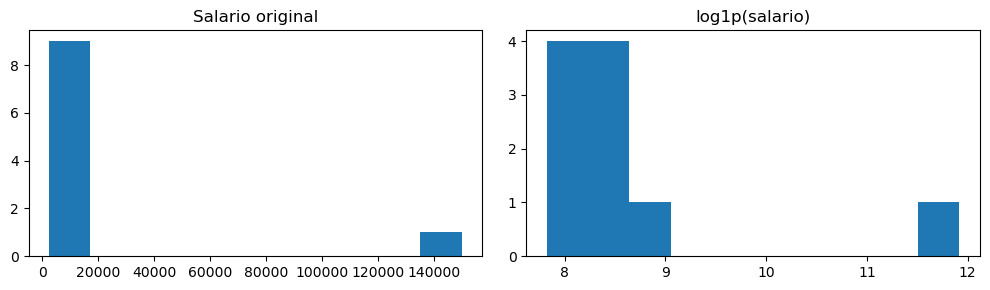

In [14]:
df_log = df.copy()
salario_sem_nulos = df_log['salario'].fillna(df_log['salario'].median())

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.hist(salario_sem_nulos, bins=10)
plt.title('Salario original')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(salario_sem_nulos), bins=10)
plt.title('log1p(salario)')

plt.tight_layout()
plt.show()

# 4. Codificação de variáveis categóricas

## 4.1 Label Encoding

Transforma categorias em inteiros.
Use principalmente em dois casos:
1. no **target**;
2. em categorias **ordinais** (quando há ordem real).

### Exemplo 1: target

In [15]:
le_target = LabelEncoder()
y_codificado = le_target.fit_transform(df['diagnostico'])
print("Classes do target:", list(le_target.classes_))
print("Target codificado:", y_codificado)

Classes do target: ['nao', 'sim']
Target codificado: [0 1 0 1 1 0 0 1 0 1]


### Exemplo 2: categoria ordinal

A variável `risco` possui ordem natural:
- baixo
- medio
- alto

Aqui, usar números faz sentido.

In [16]:
mapa_risco = {'baixo': 0, 'medio': 1, 'alto': 2}
df_ord = df.copy()
df_ord['risco_label'] = df_ord['risco'].map(mapa_risco)
df_ord[['risco', 'risco_label']]

,risco,risco_label
0,baixo,0
1,alto,2
2,baixo,0
3,alto,2
4,medio,1
5,baixo,0
6,medio,1
7,alto,2
8,baixo,0
9,medio,1


### Por que não usar Label Encoding em variáveis nominais?

Se aplicarmos Label Encoding em `cidade`, criaremos uma ordem artificial entre categorias que não têm hierarquia.

In [17]:
le_cidade = LabelEncoder()
cidade_cod = le_cidade.fit_transform(df['cidade'].fillna('desconhecida'))
pd.DataFrame({
    'cidade': df['cidade'].fillna('desconhecida'),
    'cidade_label': cidade_cod
})

,cidade,cidade_label
0,A,0
1,B,1
2,A,0
3,C,2
4,B,1
5,A,0
6,C,2
7,B,1
8,desconhecida,3
9,A,0


Nesse caso, a codificação existe, mas a ordem numérica `A < B < C` não tem significado semântico.
Por isso, para variáveis nominais, o mais adequado costuma ser **One-Hot Encoding**.

## 4.2 One-Hot Encoding com `pd.get_dummies`

Cada categoria vira uma coluna binária.
É adequado para variáveis categóricas nominais.

In [18]:
df_dummies = pd.get_dummies(df.fillna({'sexo': 'desconhecido', 'cidade': 'desconhecida'}), columns=['sexo', 'cidade'], dtype=int)
df_dummies

,idade,salario,risco,diagnostico,sexo_F,sexo_M,sexo_desconhecido,cidade_A,cidade_B,cidade_C,cidade_desconhecida
0,23.0,2500.0,baixo,nao,1,0,0,1,0,0,0
1,45.0,5200.0,alto,sim,0,1,0,0,1,0,0
2,31.0,3100.0,baixo,nao,1,0,0,1,0,0,0
3,52.0,6100.0,alto,sim,0,1,0,0,0,1,0
4,46.0,NaN,medio,sim,1,0,0,0,1,0,0
5,NaN,2800.0,baixo,nao,0,1,0,1,0,0,0
6,28.0,3300.0,medio,nao,0,0,1,0,0,1,0
7,100.0,150000.0,alto,sim,0,1,0,0,1,0,0
8,39.0,4200.0,baixo,nao,1,0,0,0,0,0,1
9,41.0,3900.0,medio,sim,1,0,0,1,0,0,0


## 4.3 One-Hot Encoding com `OneHotEncoder`

No ecossistema scikit-learn, `OneHotEncoder` é muito útil porque:
- aprende categorias no treino;
- reaplica a mesma estrutura no teste;
- lida melhor com produção e reuso.

In [19]:
df_ohe = df.copy()
df_ohe[['sexo', 'cidade']] = SimpleImputer(strategy='most_frequent').fit_transform(df_ohe[['sexo', 'cidade']])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df_ohe[['sexo', 'cidade']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['sexo', 'cidade'])
)

encoded_df

,sexo_F,sexo_M,cidade_A,cidade_B,cidade_C
0,1.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0
5,0.0,1.0,1.0,0.0,0.0
6,1.0,0.0,0.0,0.0,1.0
7,0.0,1.0,0.0,1.0,0.0
8,1.0,0.0,1.0,0.0,0.0
9,1.0,0.0,1.0,0.0,0.0


# 5. Escalonamento: normalização e padronização

Alguns algoritmos são muito sensíveis à escala das variáveis, especialmente:
- KNN;
- SVM;
- K-Means;
- regressão linear;
- redes neurais.

Árvores e Random Forest costumam não depender de escala.

Vamos usar apenas as variáveis numéricas para mostrar a diferença.

In [20]:
df_scale = df.copy()
df_scale['idade'] = df_scale['idade'].fillna(df_scale['idade'].median())
df_scale['salario'] = df_scale['salario'].fillna(df_scale['salario'].median())

X_num = df_scale[['idade', 'salario']]
X_num

,idade,salario
0,23.0,2500.0
1,45.0,5200.0
2,31.0,3100.0
3,52.0,6100.0
4,46.0,3900.0
5,41.0,2800.0
6,28.0,3300.0
7,100.0,150000.0
8,39.0,4200.0
9,41.0,3900.0


## 5.1 Normalização com `MinMaxScaler`

Traz os valores para uma faixa definida, normalmente `[0,1]`.

### Fórmula

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

In [21]:
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(X_num), columns=X_num.columns)
X_minmax

,idade,salario
0,0.000000,0.000000
1,0.285714,0.018305
2,0.103896,0.004068
3,0.376623,0.024407
4,0.298701,0.009492
5,0.233766,0.002034
6,0.064935,0.005424
7,1.000000,1.000000
8,0.207792,0.011525
9,0.233766,0.009492


## 5.2 Padronização com `StandardScaler`

Centraliza os dados em média 0 e desvio padrão 1.

### Fórmula

$$
z = \frac{x - \mu}{\sigma}
$$

In [22]:
standard = StandardScaler()
X_standard = pd.DataFrame(standard.fit_transform(X_num), columns=X_num.columns)
X_standard

,idade,salario
0,-1.065398,-0.364917
1,0.019730,-0.303337
2,-0.670806,-0.351232
3,0.364997,-0.282810
4,0.069054,-0.332986
5,-0.177566,-0.358074
6,-0.818778,-0.346671
7,2.732548,2.999158
8,-0.276214,-0.326144
9,-0.177566,-0.332986


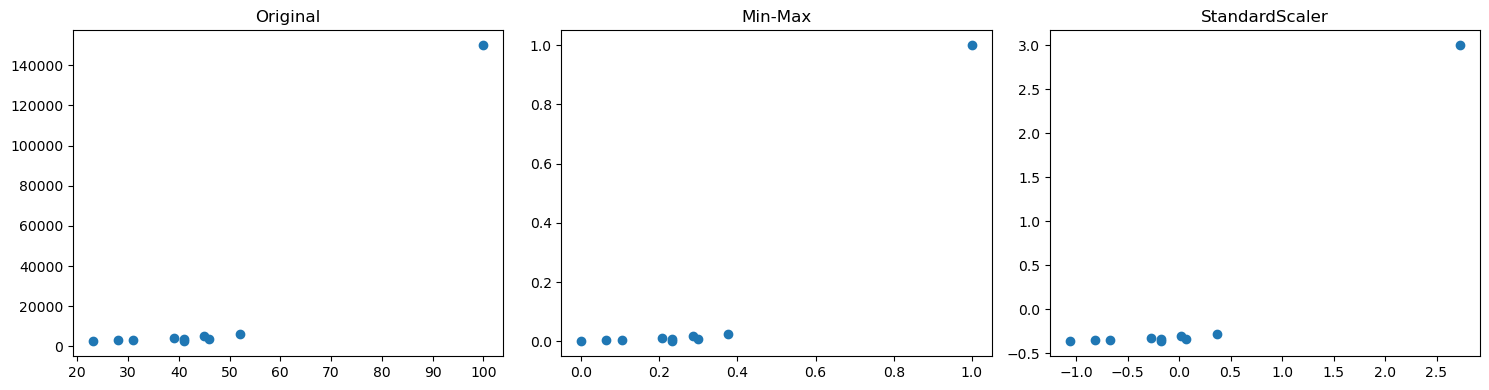

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_num['idade'], X_num['salario'])
axes[0].set_title('Original')

axes[1].scatter(X_minmax['idade'], X_minmax['salario'])
axes[1].set_title('Min-Max')

axes[2].scatter(X_standard['idade'], X_standard['salario'])
axes[2].set_title('StandardScaler')

plt.tight_layout()
plt.show()

## 5.3 Quando usar cada um?

### Min-Max
Prefira quando:
- quer faixa fixa;
- vai usar redes neurais;
- não há outliers extremos.

### StandardScaler
Prefira quando:
- os dados podem conter valores extremos;
- o algoritmo assume distribuição aproximadamente centrada;
- vai usar regressão linear, SVM ou PCA.

### Importante
Nem Min-Max nem StandardScaler "resolvem" outliers.
Eles apenas mudam a escala.

# 6. Exemplo completo de pré-processamento para classificação

Agora vamos montar um fluxo simples e coerente:
1. separar `X` e `y`;
2. dividir treino e teste;
3. imputar nulos;
4. codificar categóricos;
5. treinar modelo;
6. avaliar.

Vamos usar uma árvore de decisão.

In [24]:
df_modelo = df.copy()

X = df_modelo.drop(columns=['diagnostico'])
y = df_modelo['diagnostico']

# target
le = LabelEncoder()
y = le.fit_transform(y)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# imputação manual simples
num_fill_values = {}
for col in num_cols:
    valor = X_train[col].median()
    num_fill_values[col] = valor
    X_train.loc[:, col] = X_train[col].fillna(valor)
    X_test.loc[:, col] = X_test[col].fillna(valor)

cat_fill_values = {}
for col in cat_cols:
    valor = X_train[col].mode()[0]
    cat_fill_values[col] = valor
    X_train.loc[:, col] = X_train[col].fillna(valor)
    X_test.loc[:, col] = X_test[col].fillna(valor)

# one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_train_final = pd.concat([X_train[num_cols], X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[num_cols], X_test_cat_df], axis=1)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_final, y_train)

pred = model.predict(X_test_final)
print("Acurácia:", accuracy_score(y_test, pred))
print("Classes:", list(le.classes_))
X_train_final.head()

Acurácia: 0.6666666666666666
Classes: ['nao', 'sim']


,idade,salario,sexo_F,sexo_M,cidade_A,cidade_B,cidade_C,risco_alto,risco_baixo,risco_medio
3,52.0,6100.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
8,39.0,4200.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,31.0,3100.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,100.0,150000.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,46.0,4700.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# 7. Relação entre pré-processamento e tipo de algoritmo

## Regressão linear / logística
- geralmente se beneficiam de padronização;
- sofrem com outliers;
- exigem codificação correta de categóricos.

## KNN
- depende fortemente de escala;
- muito sensível a outliers;
- precisa de variáveis numéricas.

## SVM
- normalmente exige padronização;
- sensível a outliers;
- exige cuidado com escala.

## K-Means
- depende de distância;
- exige escala comparável;
- sofre com outliers.

## Árvores e Random Forest
- não precisam de normalização/padronização;
- lidam melhor com outliers;
- ainda exigem tratamento de nulos e codificação de categóricos.

# 8. Resumo final

## Valores ausentes
- média: numérico sem forte assimetria;
- mediana: numérico com outliers;
- moda: categórico;
- remoção: quando a perda é aceitável.

## Encoding
- label encoding: target e categorias ordinais;
- one-hot: categorias nominais.

## Escalonamento
- Min-Max: intervalo fixo;
- StandardScaler: média 0 e desvio 1.

## Outliers
- detectar;
- decidir entre remover, limitar ou transformar;
- sempre considerar o algoritmo.

## Regra prática
O melhor pré-processamento não é universal.
Ele depende:
- do dado;
- da tarefa;
- do modelo.

# 9. Exercícios sugeridos

1. Substitua a imputação de `salario` por média e compare com mediana.
2. Aplique `LabelEncoder` em `cidade` e discuta por que isso pode ser inadequado.
3. Treine um KNN com dados sem escala e depois com `StandardScaler`.
4. Remova o outlier de `salario` e compare os resultados.
5. Troque `OneHotEncoder` por `pd.get_dummies` e compare o fluxo.